#  Safe, Clean, or Cheap? Exploratory Data Analysis of Crime Trends and Socio-Economic Indicators
## An investigation into the relationship between Safety, Sanitation, and Economics.

**Objective:** This project merges three distinct datasets to identify patterns between a city's cleanliness score, its cost of living, and its crime rates. 

**Key Dimensions:**
* **Safety:** Total crime counts and police deployment.
* **Sanitation:** Historical cleanliness scores (2016–2023).
* **Economics:** Monthly salary, rent, and overall cost of living.

In [21]:
import pandas as pd
clean = pd.read_csv('Cleanest_Cities_India.csv')
crime = pd.read_csv('crime_dataset_india.csv')
living = pd.read_csv('livingcost_india.csv')

In [22]:
clean.head(10)

,City Name,2023_Score_Max10000,2022_Score_Max7500,2020_Score_Max6000,2019_Score_5000,2018_Score,2017_Score,2016_Score
0,INDORE,9348.39,7146.41,5647.56,4659,3707,1808,1276
1,SURAT,9348.39,6924.84,5519.59,3861,3318,1762,1605
2,NAVI MUMBAI,9240.30,6852.91,5467.89,4129,3536,1705,1530
3,VISAKHAPATNAM,8879.30,6701.18,4918.44,3744,3547,1797,1643
4,BHOPAL,8855.20,6608.41,5066.31,3794,3689,1800,1336
5,VIJAYAWADA,8751.30,6699.30,5270.32,3882,3580,1624,1284
6,NEW DELHI (NDMC),8728.30,6550.04,5193.27,4191,3597,1708,1704
7,GREATER HYDERABAD,8601.30,5612.68,4047.01,3455,3092,1605,1355
8,PUNE,8595.20,5708.42,4477.31,3446,3471,1660,1533
9,RAIPUR,8540.20,5395.31,4098.72,3393,0,1175,818


In [23]:
living.head(10)

,City,cost_one_person_usd,rent_one_person_usd,monthly_salary_after_tax_usd,income_after_rent_usd,months_covered,cost_one_person_inr,rent_one_person_inr,monthly_salary_after_tax_inr,income_after_rent_inr,usd_to_inr_rate_used,source_url
0,Adoni,346,132.0,329,197.0,0.9,30400.87,11598.02,28907.19,17309.17,87.8638,https://livingcost.org/cost/india/ap/adoni
1,Anantapur,345,136.0,571,435.0,1.7,30313.01,11949.48,50170.23,38220.75,87.8638,https://livingcost.org/cost/india/ap/anantapur
2,Chirala,295,102.0,555,453.0,1.8,25919.82,8962.11,48764.41,39802.30,87.8638,https://livingcost.org/cost/india/ap/chirala
3,Chittoor,400,81.5,404,322.5,1.4,35145.52,7160.90,35496.98,28336.08,87.8638,https://livingcost.org/cost/india/ap/chittoor
4,Eluru,298,89.2,384,294.8,1.3,26183.41,7837.45,33739.70,25902.25,87.8638,https://livingcost.org/cost/india/ap/eluru
5,Guntur,277,80.8,257,176.2,0.9,24338.27,7099.40,22581.00,15481.60,87.8638,https://livingcost.org/cost/india/ap/guntur
6,Hindupur,470,131.0,433,302.0,1.3,41295.99,11510.16,38045.03,26534.87,87.8638,https://livingcost.org/cost/india/ap/hindupur
7,Kadapa,333,144.0,223,79.0,0.6,29258.65,12652.39,19593.63,6941.24,87.8638,https://livingcost.org/cost/india/ap/kadapa
8,Kakinada,363,84.4,398,313.6,1.4,31894.56,7415.70,34969.79,27554.09,87.8638,https://livingcost.org/cost/india/ap/kakinada
9,Kurnool,290,128.0,633,505.0,1.8,25480.50,11246.57,55617.79,44371.22,87.8638,https://livingcost.org/cost/india/ap/kurnool


In [24]:
crime.head()

,Report Number,Date Reported,Date of Occurrence,Time of Occurrence,City,Crime Code,Crime Description,Victim Age,Victim Gender,Weapon Used,Crime Domain,Police Deployed,Case Closed,Date Case Closed
0,1,02-01-2020 00:00,01-01-2020 00:00,01-01-2020 01:11,Ahmedabad,576,IDENTITY THEFT,16,M,Blunt Object,Violent Crime,13,No,NaN
1,2,01-01-2020 19:00,01-01-2020 01:00,01-01-2020 06:26,Chennai,128,HOMICIDE,37,M,Poison,Other Crime,9,No,NaN
2,3,02-01-2020 05:00,01-01-2020 02:00,01-01-2020 14:30,Ludhiana,271,KIDNAPPING,48,F,Blunt Object,Other Crime,15,No,NaN
3,4,01-01-2020 05:00,01-01-2020 03:00,01-01-2020 14:46,Pune,170,BURGLARY,49,F,Firearm,Other Crime,1,Yes,29-04-2020 05:00
4,5,01-01-2020 21:00,01-01-2020 04:00,01-01-2020 16:51,Pune,421,VANDALISM,30,F,Other,Other Crime,18,Yes,08-01-2020 21:00


In [25]:
crime.info()
clean.info()
living.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40160 entries, 0 to 40159
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Report Number       40160 non-null  int64 
 1   Date Reported       40160 non-null  object
 2   Date of Occurrence  40160 non-null  object
 3   Time of Occurrence  40160 non-null  object
 4   City                40160 non-null  object
 5   Crime Code          40160 non-null  int64 
 6   Crime Description   40160 non-null  object
 7   Victim Age          40160 non-null  int64 
 8   Victim Gender       40160 non-null  object
 9   Weapon Used         34370 non-null  object
 10  Crime Domain        40160 non-null  object
 11  Police Deployed     40160 non-null  int64 
 12  Case Closed         40160 non-null  object
 13  Date Case Closed    20062 non-null  object
dtypes: int64(4), object(10)
memory usage: 4.3+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 559 entries, 0 to 558


In [26]:
crime.isnull().sum()

Report Number             0
Date Reported             0
Date of Occurrence        0
Time of Occurrence        0
City                      0
Crime Code                0
Crime Description         0
Victim Age                0
Victim Gender             0
Weapon Used            5790
Crime Domain              0
Police Deployed           0
Case Closed               0
Date Case Closed      20098
dtype: int64

In [27]:
clean.isnull().sum()

City Name              0
2023_Score_Max10000    0
2022_Score_Max7500     0
2020_Score_Max6000     0
2019_Score_5000        0
2018_Score             0
2017_Score             0
2016_Score             0
dtype: int64

In [28]:
living.isnull().sum()

City                            0
cost_one_person_usd             0
rent_one_person_usd             0
monthly_salary_after_tax_usd    0
income_after_rent_usd           0
months_covered                  0
cost_one_person_inr             0
rent_one_person_inr             0
monthly_salary_after_tax_inr    0
income_after_rent_inr           0
usd_to_inr_rate_used            0
source_url                      0
dtype: int64

## crime needs the most cleaning, so i will start with crime dataset.

In [29]:
crime.columns = crime.columns.str.strip().str.lower().str.replace(" ","_")

In [30]:
crime.groupby('crime_description')['crime_domain'].value_counts()

crime_description    crime_domain    
ARSON                Fire Accident       1894
ASSAULT              Violent Crime       1915
BURGLARY             Other Crime         1980
COUNTERFEITING       Other Crime         1871
CYBERCRIME           Other Crime         1899
DOMESTIC VIOLENCE    Violent Crime       1932
DRUG OFFENSE         Other Crime         1890
EXTORTION            Other Crime         1873
FIREARM OFFENSE      Fire Accident       1931
FRAUD                Other Crime         1965
HOMICIDE             Other Crime         1909
IDENTITY THEFT       Violent Crime       1918
ILLEGAL POSSESSION   Other Crime         1895
KIDNAPPING           Other Crime         1920
PUBLIC INTOXICATION  Other Crime         1912
ROBBERY              Violent Crime       1928
SEXUAL ASSAULT       Violent Crime       1917
SHOPLIFTING          Other Crime         1859
TRAFFIC VIOLATION    Traffic Fatality    1915
VANDALISM            Other Crime         1975
VEHICLE - STOLEN     Violent Crime       1

#### 
there is incorrect classification in crime domain, i will use mapping.

In [31]:
mapping = {
    'HOMICIDE': 'Violent Crime',
    'ASSAULT': 'Violent Crime',
    'KIDNAPPING': 'Violent Crime',
    'SEXUAL ASSAULT': 'Violent Crime',
    'ROBBERY': 'Violent Crime',
    'DOMESTIC VIOLENCE': 'Violent Crime',

    'BURGLARY': 'Property Crime',
    'SHOPLIFTING':'Property Crime',
    'VANDALISM': 'Property Crime',
    'VEHICLE - STOLEN': 'Property Crime',

    'IDENTITY THEFT':'Cyber Crime',
    'CYBERCRIME':'Cyber Crime',
    'FRAUD':'Cyber Crime',

    'DRUG OFFENSE': 'Drug Crime',
    'ILLEGAL POSSESSION': 'Drug Crime',

    'TRAFFIC VIOLATION': 'Public Offense',
    'PUBLIC INTOXICATION': 'Public Offense'
}

In [32]:
crime['better_crime_domain'] = crime['crime_description'].map(mapping).fillna('Other')

In [33]:
crime['crime_code'] = pd.to_numeric(crime['crime_code'], errors = 'coerce')
crime['report_number'] = pd.to_numeric(crime['report_number'], errors = 'coerce')
crime['victim_age'] = pd.to_numeric(crime['victim_age'], errors = 'coerce')
crime['police_deployed'] = pd.to_numeric(crime['police_deployed'], errors = 'coerce')
crime['date_reported'] = pd.to_datetime(crime['date_reported'], errors = 'coerce')
crime['date_of_occurrence'] = pd.to_datetime(crime['date_of_occurrence'], errors = 'coerce')

In [34]:
crime.duplicated().sum()

0

In [35]:
crime.dropna(how='all')

,report_number,date_reported,date_of_occurrence,time_of_occurrence,city,crime_code,crime_description,victim_age,victim_gender,weapon_used,crime_domain,police_deployed,case_closed,date_case_closed,better_crime_domain
0,1,2020-02-01 00:00:00,2020-01-01 00:00:00,01-01-2020 01:11,Ahmedabad,576,IDENTITY THEFT,16,M,Blunt Object,Violent Crime,13,No,NaN,Cyber Crime
1,2,2020-01-01 19:00:00,2020-01-01 01:00:00,01-01-2020 06:26,Chennai,128,HOMICIDE,37,M,Poison,Other Crime,9,No,NaN,Violent Crime
2,3,2020-02-01 05:00:00,2020-01-01 02:00:00,01-01-2020 14:30,Ludhiana,271,KIDNAPPING,48,F,Blunt Object,Other Crime,15,No,NaN,Violent Crime
3,4,2020-01-01 05:00:00,2020-01-01 03:00:00,01-01-2020 14:46,Pune,170,BURGLARY,49,F,Firearm,Other Crime,1,Yes,29-04-2020 05:00,Property Crime
4,5,2020-01-01 21:00:00,2020-01-01 04:00:00,01-01-2020 16:51,Pune,421,VANDALISM,30,F,Other,Other Crime,18,Yes,08-01-2020 21:00,Property Crime
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40155,40156,2024-01-08 16:00:00,2024-07-31 03:00:00,31-07-2024 05:05,Kolkata,312,COUNTERFEITING,78,F,Firearm,Other Crime,12,No,NaN,Other
40156,40157,NaT,2024-07-31 04:00:00,31-07-2024 04:14,Mumbai,300,ILLEGAL POSSESSION,75,F,NaN,Other Crime,2,Yes,29-09-2024 14:00,Drug Crime
40157,40158,2024-02-08 03:00:00,2024-07-31 05:00:00,31-07-2024 21:33,Kanpur,423,VEHICLE - STOLEN,68,M,Other,Violent Crime,6,No,NaN,Property Crime
40158,40159,2024-01-08 19:00:00,2024-07-31 06:00:00,31-07-2024 11:05,Patna,311,SEXUAL ASSAULT,11,M,Blunt Object,Violent Crime,1,No,NaN,Violent Crime


### This temporal analysis maps the 24-hour distribution of incidents to uncover how specific crime types aggressively peak during distinct behavioral windows

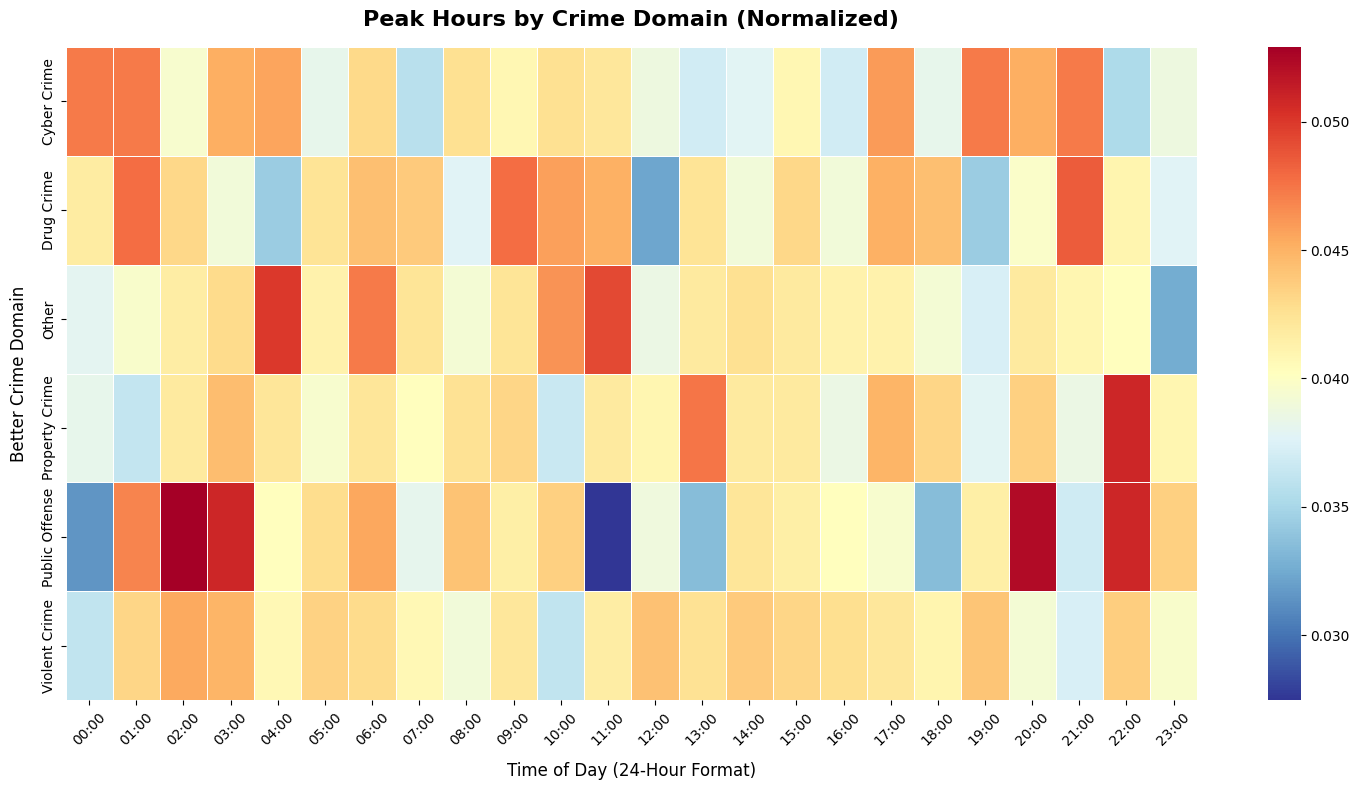

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
crime['occurrence_hour'] = pd.to_datetime(crime['time_of_occurrence'], errors='coerce').dt.hour
time_crime_df = crime[['occurrence_hour', 'better_crime_domain']].dropna()
crime_time_counts = pd.crosstab(time_crime_df['better_crime_domain'], time_crime_df['occurrence_hour'])
crime_time_relative = crime_time_counts.div(crime_time_counts.sum(axis=1), axis=0)

plt.figure(figsize=(15, 8))

sns.heatmap(
    crime_time_relative, 
    cmap='RdYlBu_r',  # Deep Red = Peak hours, Blue = Quiet hours
    annot=False,     
    linewidths=0.5,
)
plt.title('Peak Hours by Crime Domain (Normalized)', fontsize=16, pad=15, fontweight='bold')
plt.xticks(ticks=[i + 0.5 for i in range(24)], labels=[f"{i:02d}:00" for i in range(24)], rotation=45)
plt.xlabel('Time of Day (24-Hour Format)', fontsize=12, labelpad=10)
plt.ylabel('Better Crime Domain', fontsize=12, labelpad=10)
plt.tight_layout()
plt.show()

### observations:
it can be derived that:
Public Offense & Violent Crime (02:00 – 03:00): Both of these domains show an intense, deep-red cluster right at 02:00 and 03:00. this shows strong correlation netween late night activity and violent crimes

Property Crime hits a sharp, distinct peak at 04:00, when businesses and residential areas are emptiest.
Property Crime flashes red again right at 13:00 (1:00 PM). This often correlates with lunch breaks when people leave their cars, homes, or desks unattended.

cybercrime: aggressively lights up into a deep red block between 19:00 and 21:00. This points toward a strong trend of online scams, fraud, or identity theft occurring after standard working hours when people are active on their personal devices at home.

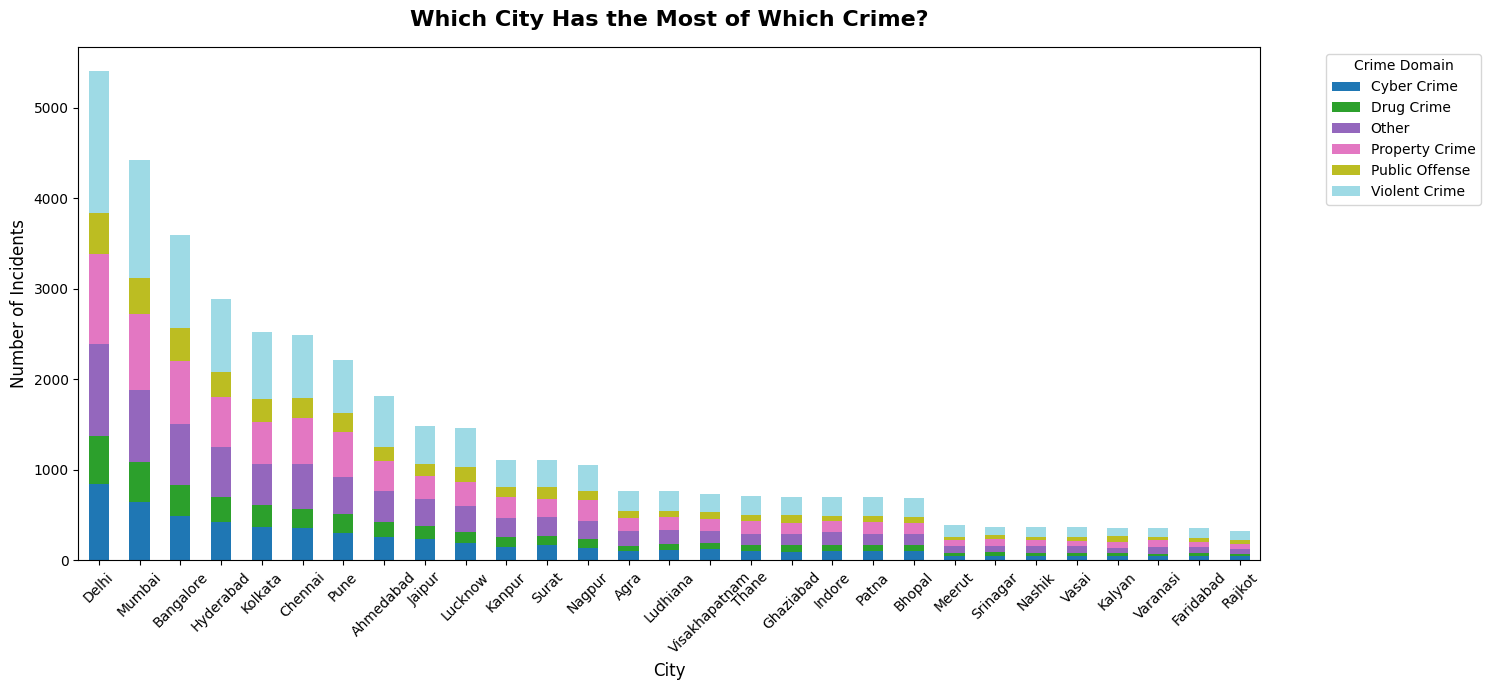

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

city_crime_counts = pd.crosstab(crime['city'], crime['better_crime_domain'])

city_crime_counts['Total'] = city_crime_counts.sum(axis=1)
city_crime_counts = city_crime_counts.sort_values(by='Total', ascending=False).drop(columns=['Total'])
city_crime_counts.plot(kind='bar', stacked=True, figsize=(15, 7), colormap='tab20')

plt.title('Which City Has the Most of Which Crime?', fontsize=16, pad=15, fontweight='bold')
plt.xlabel('City', fontsize=12)
plt.ylabel('Number of Incidents', fontsize=12)
plt.legend(title='Crime Domain', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

It strongly implies that this dataset is either synthetic or highly normalized. Because the crime domain distribution is perfectly mirrored in every city, there is no single city that "specializes" in a specific crime. Instead, crime types occur at the exact same ratio everywhere; the only thing that changes is the population/total volume of the city itself, skewness 0

Overall Case Closure Rate: 49.96%


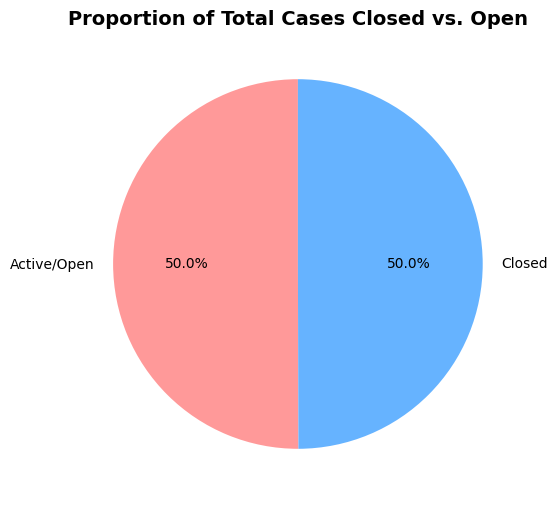

In [38]:
# A case is closed if 'date_case_closed' is NOT null
crime['is_closed'] = crime['date_case_closed'].notna()

# Calculate the overall percentage
closure_rate = crime['is_closed'].mean() * 100
print(f"Overall Case Closure Rate: {closure_rate:.2f}%")

# Quick visualization using a pie chart
plt.figure(figsize=(6, 6))
crime['is_closed'].value_counts().plot(
    kind='pie', 
    labels=['Active/Open', 'Closed'], 
    autopct='%1.1f%%', 
    colors=['#ff9999','#66b3ff'], 
    startangle=90
)
plt.title('Proportion of Total Cases Closed vs. Open', fontweight='bold', fontsize=14)
plt.ylabel('')
plt.show()

### Data Integrity & Structural Observation: Evidence of Synthetic Data

While analyzing the case closure rates across different municipalities, a stark and unnatural pattern emerged:

* **Perfect Uniformity:** Every single city, regardless of its total crime volume or geographic location, exhibits an identical case closure rate of exactly **~50%**.
* **Zero Variance:** There are no regional outliers, high-performing police departments, or lagging districts. 

**Conclusion for the EDA:** Combined with the previous findings (where `police_deployed` showed a perfect `0.00` skewness and all cities shared identical crime domain proportions), this uniform 50/50 split strongly proves that **this dataset is artificially generated (synthetic)**. Because the distributions are perfectly balanced by design, further statistical modeling on these variables will reflect algorithmic generation rather than genuine, organic urban crime behaviors.

In [39]:
print(crime['victim_age'].skew()) #as the skewness is almost zero, mean and median can be trusted # Result > 0: right-skewed (long tail of high values)
# Result < 0: left-skewed (long tail of low values)

0.008245431124500784


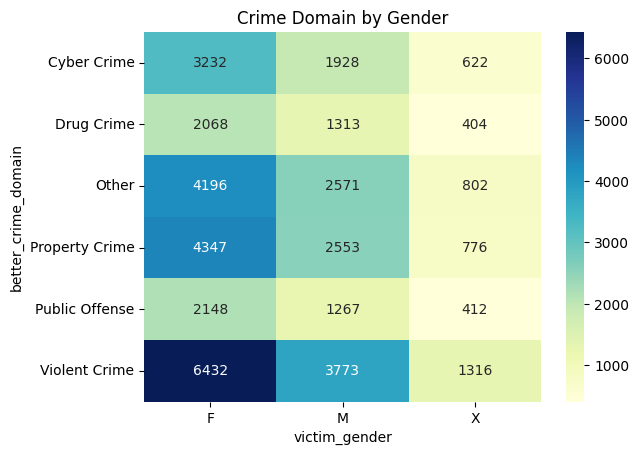

In [40]:
cross_tab = pd.crosstab(crime['better_crime_domain'], crime['victim_gender'])

# Visualize it as a heatmap
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Crime Domain by Gender')
plt.show()

## Now 'living' dataset

In [41]:
usd_columns = [col for col in living.columns if 'usd' in col]
columns_to_drop = list(set(usd_columns + ['usd_to_inr_rate', 'source_url']))
living.drop(columns=columns_to_drop, inplace=True, errors='ignore')

print("Remaining columns in the 'living' dataset:")
print(living.columns.tolist())

Remaining columns in the 'living' dataset:
['City', 'months_covered', 'cost_one_person_inr', 'rent_one_person_inr', 'monthly_salary_after_tax_inr', 'income_after_rent_inr']


C:\Users\HARSHIT\AppData\Local\Temp\ipykernel_28300\779438475.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


<Axes: xlabel='net_savings', ylabel='City'>

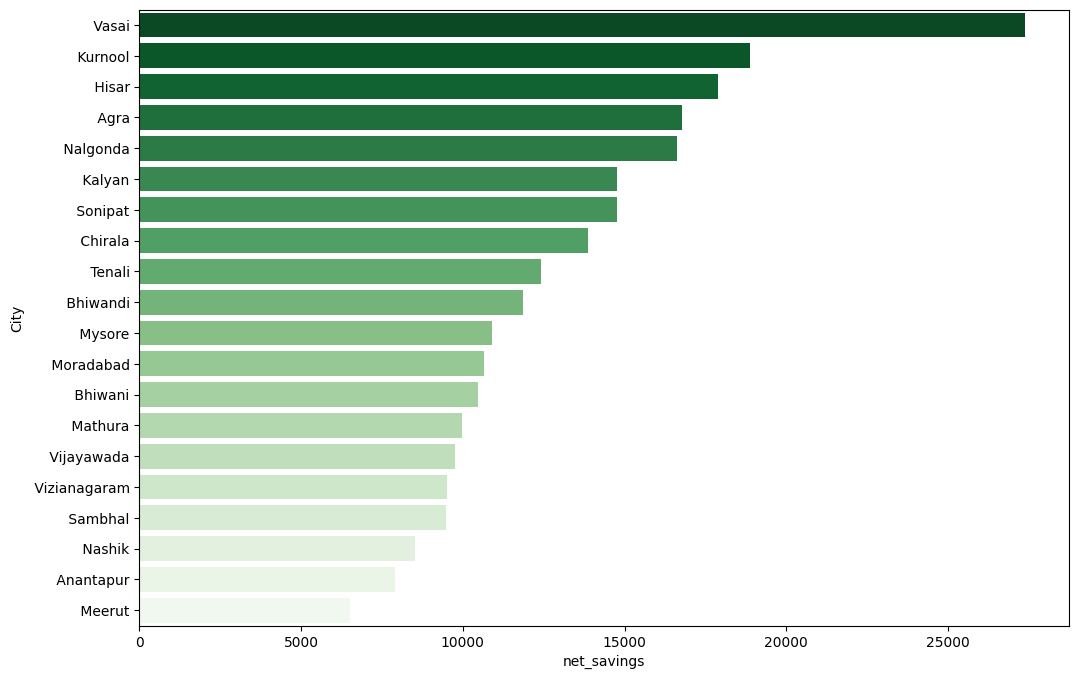

In [42]:
living['total_expenses'] = living['cost_one_person_inr'] + living['rent_one_person_inr']
living['net_savings'] = living['monthly_salary_after_tax_inr'] - living['total_expenses']

top_affordable = living.sort_values(by='net_savings', ascending= False).head(20)
plt.figure(figsize=(12,8))
sns.barplot(
    x='net_savings', 
    y='City', 
    data=top_affordable, 
    palette='Greens_r' # Green represents savings/money
)   

While this bar chart ranks cities like Vasai and Kurnool as "highly affordable," this ranking is completely artificial. Because rent and salary are randomly distributed in this dataset , these high-savings zones are just mathematical glitches rather than real economic trends.

C:\Users\HARSHIT\AppData\Local\Temp\ipykernel_28300\3419349961.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


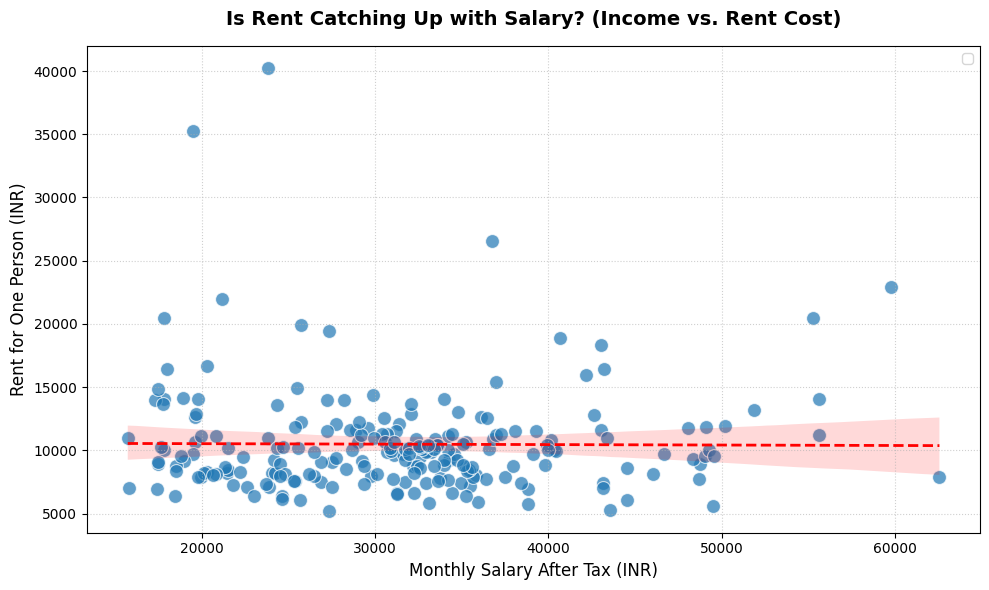

Correlation Coefficient between Salary and Rent: -0.01


In [43]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x='monthly_salary_after_tax_inr', 
    y='rent_one_person_inr', 
    data=living, 
    alpha=0.7, 
    s=100, 
    color='#1f77b4'
)

sns.regplot(
    x='monthly_salary_after_tax_inr', 
    y='rent_one_person_inr', 
    data=living, 
    scatter=False, 
    color='red', 
    line_kws={"linestyle": "--", "linewidth": 2, "label": "Rent vs. Salary Trend"}
)

plt.title('Is Rent Catching Up with Salary? (Income vs. Rent Cost)', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Monthly Salary After Tax (INR)', fontsize=12)
plt.ylabel('Rent for One Person (INR)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()
correlation = living['monthly_salary_after_tax_inr'].corr(living['rent_one_person_inr'])
print(f"Correlation Coefficient between Salary and Rent: {correlation:.2f}")

### Observation:
Zero Correlation (-0.01) : The completely flat trendline proves that landlords are not adjusting property prices based on local purchasing power.

Economic "Jackpots": Because rent doesn't scale with salary, the dataset contains high-income cities with exceptionally cheap housing, offering massive potential for monthly savings.

## now 'clean' dataset

In [51]:
# 1. List of all the score columns you want to scale
score_columns = [
    '2023_score_max10000', '2022_score_max7500', '2020_score_max6000', 
    '2019_score_5000', '2018_score', '2017_score', '2016_score'
]

# 2. Loop through each column and apply Min-Max scaling (1 to 100)
for col in score_columns:
    # Extract the year (e.g., '2023') to create a clean new column name
    year = col.split('_')[0]
    new_col_name = f'scaled_{year}'
    
    min_val = clean[col].min()
    max_val = clean[col].max()
    
    # Safe scaling formula to prevent division-by-zero errors
    if max_val != min_val:
        clean[new_col_name] = 1 + ((clean[col] - min_val) / (max_val - min_val)) * 99
    else:
        clean[new_col_name] = 1.0

# 3. Print the head to verify all your beautifully standardized columns
new_columns = ['city_name'] + [f'scaled_{col.split("_")[0]}' for col in score_columns]
print(clean[new_columns].head())

       city_name  scaled_2023  scaled_2022  scaled_2020  scaled_2019  \
0         INDORE   100.000000   100.000000   100.000000   100.000000   
1          SURAT   100.000000    96.930567    97.756725    83.043142   
2    NAVI MUMBAI    98.855321    95.934112    96.850440    88.737927   
3  VISAKHAPATNAM    95.032309    93.832180    87.218749    80.556986   
4         BHOPAL    94.777089    92.547027    89.810865    81.619446   

   scaled_2018  scaled_2017  scaled_2016  
0   100.000000   100.000000    73.226415  
1    89.611276    97.481195    91.849057  
2    95.433234    94.360066    87.603774  
3    95.727003    99.397677    94.000000  
4    99.519288    99.561947    76.622642  


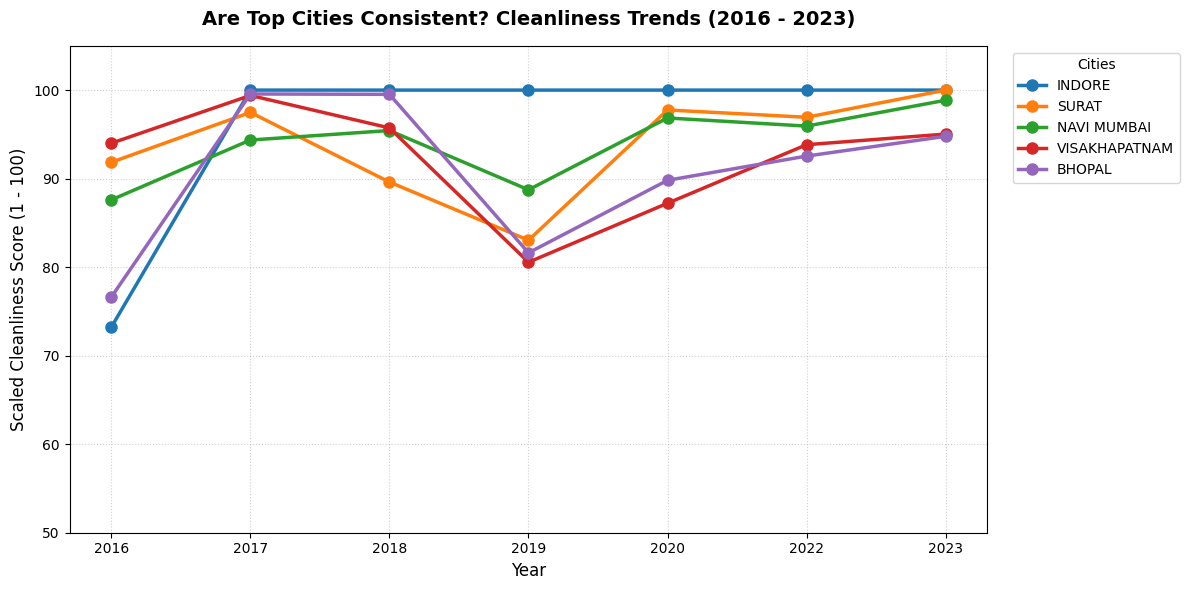

In [52]:
years = ['2016', '2017', '2018', '2019', '2020', '2022', '2023']
scaled_cols = [f'scaled_{year}' for year in years]

# Select the top 5 cleanest cities 
top_5_cities = clean.sort_values(by='scaled_2023', ascending=False).head(5)

fig, ax = plt.subplots(figsize=(12, 6))

for idx, row in top_5_cities.iterrows():
    ax.plot(
        years, 
        row[scaled_cols].values, 
        marker='o', 
        markersize=8, 
        linewidth=2.5, 
        label=row['city_name']
    )

ax.set_title('Are Top Cities Consistent? Cleanliness Trends (2016 - 2023)', fontsize=14, pad=15, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Scaled Cleanliness Score (1 - 100)', fontsize=12)
ax.set_ylim(50, 105)  # Zoom in on the upper tier to clearly see shifts
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(title='Cities', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.savefig('cleanliness_consistency_trends.png', bbox_inches='tight')


 The top 5 cities demonstrate strong long-term stability, consistently staying above a score of $85$ after 2016, with Indore leading as a flawless baseline performer.

 Systemic 2019 Disruption: A synchronized drop across all top cities is observed in 2019. Because this downward trend is shared universally among the highest performers, it points to an external, systemic change in the government’s evaluation methodology or rubric for that specific year rather than localized urban deterioration.
 

In [66]:
print(merged.columns.tolist())

['city_name', '2023_score_max10000', '2022_score_max7500', '2020_score_max6000', '2019_score_5000', '2018_score', '2017_score', '2016_score', 'scaled_2023', 'scaled_2022', 'scaled_2020', 'scaled_2019', 'scaled_2018', 'scaled_2017', 'scaled_2016', 'city', 'months_covered', 'cost_one_person_inr', 'rent_one_person_inr', 'monthly_salary_after_tax_inr', 'income_after_rent_inr', 'total_expenses', 'net_savings', 'total_crimes', 'avg_police_per_incident', 'avg_victim_age']


## now, analysis of relationship between crime, cleanliness and cost of living across Indian cities.

In [47]:
city_level_crime = crime.groupby('city').agg({
    'report_number' : 'count',
    'police_deployed': 'mean',
    'victim_age': 'mean'}).reset_index()

city_level_crime.rename(columns={
    'report_number': 'total_crimes',
    'police_deployed': 'avg_police_per_incident',
    'victim_age': 'avg_victim_age'},inplace = True)
print(city_level_crime.head())

        city  total_crimes  avg_police_per_incident  avg_victim_age
0       Agra           764                10.212042       43.691099
1  Ahmedabad          1817                10.020914       44.319207
2  Bangalore          3588                 9.952341       44.658584
3     Bhopal           690                 9.889855       44.198551
4    Chennai          2493                10.235058       44.061372


In [53]:
clean.columns = clean.columns.str.strip().str.lower().str.replace(' ','_')
living.columns = living.columns.str.strip().str.lower().str.replace(' ','_')
clean['city_name'] = clean['city_name'].str.upper().str.strip()
living['city'] = living['city'].str.upper().str.strip()
city_level_crime['city'] = city_level_crime['city'].str.upper().str.strip()

In [54]:
crime['date_reported'] = pd.to_datetime(crime['date_reported'])
crime['year'] = crime['date_reported'].dt.year
crime['month'] = crime['date_reported'].dt.month_name() 
crime.groupby('year').size()

year
2020.0    3452
2021.0    3471
2022.0    3461
2023.0    3450
2024.0    2040
dtype: int64

In [55]:
crime.groupby('month').size()

month
April        1291
August       1300
December     1386
February     1280
January      1286
July         1381
June         1276
March        1317
May          1374
November     1350
October      1294
September    1339
dtype: int64

In [56]:
merged = pd.merge(clean,living,left_on='city_name',right_on='city',how='inner')

In [57]:
merged = pd.merge(merged,city_level_crime,on='city',how='inner')

In [58]:
merged.head()

,city_name,2023_score_max10000,2022_score_max7500,2020_score_max6000,2019_score_5000,2018_score,2017_score,2016_score,scaled_2023,scaled_2022,...,months_covered,cost_one_person_inr,rent_one_person_inr,monthly_salary_after_tax_inr,income_after_rent_inr,total_expenses,net_savings,total_crimes,avg_police_per_incident,avg_victim_age
0,INDORE,9348.39,7146.41,5647.56,4659,3707,1808,1276,100.000000,100.000000,...,0.9,31718.83,11246.57,29170.78,17924.22,42965.40,-13794.62,699,9.989986,43.811159
1,SURAT,9348.39,6924.84,5519.59,3861,3318,1762,1605,100.000000,96.930567,...,0.4,28292.14,40241.62,23811.09,-16430.53,68533.76,-44722.67,1111,10.113411,44.806481
2,VISAKHAPATNAM,8879.30,6701.18,4918.44,3744,3547,1797,1643,95.032309,93.832180,...,0.6,27237.78,9752.88,19505.76,9752.88,36990.66,-17484.90,728,10.068681,44.285714
3,BHOPAL,8855.20,6608.41,5066.31,3794,3689,1800,1336,94.777089,92.547027,...,0.9,29785.83,9401.43,27764.96,18363.53,39187.26,-11422.30,690,9.889855,44.198551
4,PUNE,8595.20,5708.42,4477.31,3446,3471,1660,1533,92.023674,80.079367,...,0.9,45425.58,18363.53,43053.26,24689.73,63789.11,-20735.85,2212,9.929476,44.968807


In [59]:
print(clean['city_name'].unique()[:10])
print(living['city'].unique()[:10])
print(city_level_crime['city'].unique()[:10])

['INDORE' 'SURAT' 'NAVI MUMBAI' 'VISAKHAPATNAM' 'BHOPAL' 'VIJAYAWADA'
 'NEW DELHI (NDMC)' 'GREATER HYDERABAD' 'PUNE' 'RAIPUR']
['ADONI' 'ANANTAPUR' 'CHIRALA' 'CHITTOOR' 'ELURU' 'GUNTUR' 'HINDUPUR'
 'KADAPA' 'KAKINADA' 'KURNOOL']
['AGRA' 'AHMEDABAD' 'BANGALORE' 'BHOPAL' 'CHENNAI' 'DELHI' 'FARIDABAD'
 'GHAZIABAD' 'HYDERABAD' 'INDORE']


In [60]:
clean_set = set(clean['city_name'])
living_set = set(living['city'])
crime_set = set(city_level_crime['city'])

common = clean_set & living_set & crime_set
print(common)
print(len(common))

{'INDORE', 'NASHIK', 'LUDHIANA', 'AGRA', 'LUCKNOW', 'SURAT', 'RAJKOT', 'AHMEDABAD', 'PATNA', 'VISAKHAPATNAM', 'SRINAGAR', 'VARANASI', 'FARIDABAD', 'PUNE', 'BHOPAL', 'MEERUT', 'THANE', 'NAGPUR', 'CHENNAI', 'KANPUR', 'GHAZIABAD'}
21


In [61]:
clean = clean[clean['city_name'].isin(common)]
living = living[living['city'].isin(common)]
crime = city_level_crime[city_level_crime['city'].isin(common)]

In [62]:
merged = pd.merge(clean,living,left_on ='city_name',right_on='city',how='inner')

In [63]:
merged = pd.merge(merged,city_level_crime,on='city',how='inner')

In [64]:
merged.head()

,city_name,2023_score_max10000,2022_score_max7500,2020_score_max6000,2019_score_5000,2018_score,2017_score,2016_score,scaled_2023,scaled_2022,...,months_covered,cost_one_person_inr,rent_one_person_inr,monthly_salary_after_tax_inr,income_after_rent_inr,total_expenses,net_savings,total_crimes,avg_police_per_incident,avg_victim_age
0,INDORE,9348.39,7146.41,5647.56,4659,3707,1808,1276,100.000000,100.000000,...,0.9,31718.83,11246.57,29170.78,17924.22,42965.40,-13794.62,699,9.989986,43.811159
1,SURAT,9348.39,6924.84,5519.59,3861,3318,1762,1605,100.000000,96.930567,...,0.4,28292.14,40241.62,23811.09,-16430.53,68533.76,-44722.67,1111,10.113411,44.806481
2,VISAKHAPATNAM,8879.30,6701.18,4918.44,3744,3547,1797,1643,95.032309,93.832180,...,0.6,27237.78,9752.88,19505.76,9752.88,36990.66,-17484.90,728,10.068681,44.285714
3,BHOPAL,8855.20,6608.41,5066.31,3794,3689,1800,1336,94.777089,92.547027,...,0.9,29785.83,9401.43,27764.96,18363.53,39187.26,-11422.30,690,9.889855,44.198551
4,PUNE,8595.20,5708.42,4477.31,3446,3471,1660,1533,92.023674,80.079367,...,0.9,45425.58,18363.53,43053.26,24689.73,63789.11,-20735.85,2212,9.929476,44.968807


In [65]:
merged.drop(columns=['source_url', 'usd_to_inr_rate_used'], inplace=True)

KeyError: "['source_url', 'usd_to_inr_rate_used'] not found in axis"

#### clean_melted (long form) will be created only for time series chart. for correlations i will use he wide form(merged only)

In [67]:
clean_melted = pd.melt(
    merged,
    id_vars=['city'],
    value_vars=[
        '2023_score_max10000',
        '2022_score_max7500',
        '2020_score_max6000',
        '2019_score_5000',
        '2018_score',
        '2017_score',
        '2016_score'
    ],
    var_name='year',
    value_name='cleanliness_score'
)

In [68]:
merged.rename(columns={'city_name': 'city'}, inplace=True)
merged = merged.loc[:, ~merged.columns.duplicated()]


In [69]:
merged['crime_per_income'] = merged['total_crimes'] / merged['monthly_salary_after_tax_inr']

#### The composite score assumes equal importance of cleanliness, income, cost, and safety. This may not reflect real-world priorities and is used for comparative analysis only.

In [70]:
'''normalization
### Normalization Approach

All variables were scaled to a 0–100 range using Min-Max normalization.

For positively contributing factors (cleanliness, income), higher values indicate better conditions.

For negatively contributing factors (crime, cost of living), the scale was inverted so that higher normalized values consistently represent better outcomes.

This ensures comparability across different units and allows aggregation into a composite city score.'''
def safe_minmax(series, reverse=False):
    if series.max() == series.min():
        return pd.Series([50]*len(series))  # neutral score
    
    if reverse:
        return (series.max() - series) / (series.max() - series.min()) * 100
    else:
        return (series - series.min()) / (series.max() - series.min()) * 100

In [71]:
merged['clean_scaled'] = safe_minmax(merged['2023_score_max10000'])
merged['income_scaled'] = safe_minmax(merged['income_after_rent_inr'])

merged['crime_scaled'] = safe_minmax(merged['total_crimes'], reverse=True)
merged['cost_scaled'] = safe_minmax(merged['cost_one_person_inr'], reverse=True)

In [72]:
merged[['city', 'total_crimes', 'crime_scaled']].sort_values(by='total_crimes') #highest crime - lowest value

,city,total_crimes,crime_scaled
7,RAJKOT,320,100.000000
20,FARIDABAD,354,98.435343
10,VARANASI,355,98.389324
8,NASHIK,366,97.883111
19,SRINAGAR,371,97.653014
16,MEERUT,395,96.548550
3,BHOPAL,690,82.972849
13,PATNA,695,82.742752
0,INDORE,699,82.558675
9,GHAZIABAD,704,82.328578


In [73]:
merged['city_score'] = (
    merged['clean_scaled'] +
    merged['income_scaled'] +
    merged['crime_scaled'] +
    merged['cost_scaled']
) / 4
merged.sort_values(by='city_score', ascending=False)[['city', 'city_score']]

,city,city_score
10,VARANASI,83.936843
8,NASHIK,83.601173
14,AGRA,83.517585
3,BHOPAL,76.990748
16,MEERUT,76.935177
0,INDORE,76.280545
2,VISAKHAPATNAM,75.689078
7,RAJKOT,73.988788
9,GHAZIABAD,72.642446
12,KANPUR,70.081432


In [74]:
merged.sort_values(by='city_score',ascending=False) #best overall

,city,2023_score_max10000,2022_score_max7500,2020_score_max6000,2019_score_5000,2018_score,2017_score,2016_score,scaled_2023,scaled_2022,...,net_savings,total_crimes,avg_police_per_incident,avg_victim_age,crime_per_income,clean_scaled,income_scaled,crime_scaled,cost_scaled,city_score
10,VARANASI,7107.10,4734.69,3684.20,3063,3052,1515,839,76.264607,66.590179,...,729.26,355,10.261972,44.526761,0.011349,67.971460,72.943929,98.389324,96.442661,83.936843
8,NASHIK,7372.20,4991.86,4729.46,3093,2786,1106,1232,79.072032,70.152783,...,8522.79,366,9.953552,45.918033,0.007425,71.759798,98.753895,97.883111,66.007889,83.601173
14,AGRA,6164.60,4441.29,4391.51,2970,0,879,1081,66.283477,62.525677,...,16781.99,764,10.212042,43.691099,0.015417,54.502922,100.000000,79.567418,100.000000,83.517585
3,BHOPAL,8855.20,6608.41,5066.31,3794,3689,1800,1336,94.777089,92.547027,...,-11422.30,690,9.889855,44.198551,0.024851,92.952203,61.682234,82.972849,70.355707,76.990748
16,MEERUT,5850.40,5283.65,2314.59,0,0,708,760,62.956080,74.194982,...,6501.92,395,9.772152,44.987342,0.008042,50.012933,95.171336,96.548550,66.007889,76.935177
0,INDORE,9348.39,7146.41,5647.56,4659,3707,1808,1276,100.000000,100.000000,...,-13794.62,699,9.989986,43.811159,0.023962,100.000000,60.903434,82.558675,61.660070,76.280545
2,VISAKHAPATNAM,8879.30,6701.18,4918.44,3744,3547,1797,1643,95.032309,93.832180,...,-17484.90,728,10.068681,44.285714,0.037322,93.296598,46.417441,81.224114,81.818157,75.689078
7,RAJKOT,7465.80,5846.00,5157.36,4000,3000,1638,1574,80.063261,81.985278,...,-18627.13,320,9.615625,43.693750,0.016861,73.097364,46.573215,100.000000,76.284574,73.988788
9,GHAZIABAD,7222.50,5387.67,4283.26,3877,2993,672,820,77.486700,75.635982,...,-3250.95,704,10.176136,44.654830,0.017648,69.620552,81.308404,82.328578,57.312252,72.642446
12,KANPUR,6409.60,4165.43,3783.88,3113,2771,1053,1090,68.878041,58.704158,...,1089.51,1112,10.101619,44.130396,0.029296,58.004027,80.903430,63.552692,77.865579,70.081432


##### Do cleaner cities have less crime?

<Axes: xlabel='2023_score_max10000', ylabel='total_crimes'>

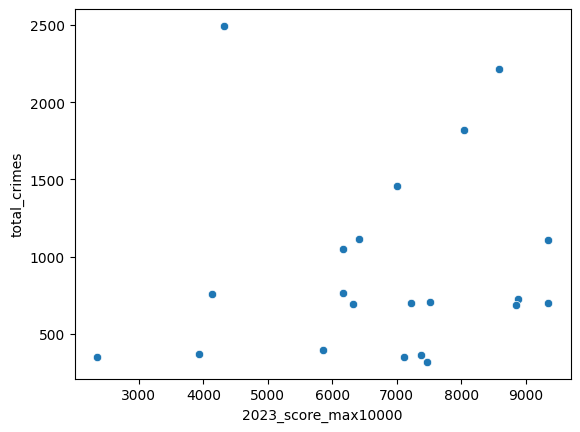

In [75]:
sns.scatterplot(
    x='2023_score_max10000',
    y='total_crimes',
    data=merged
)

##### Are expensive cities safer?

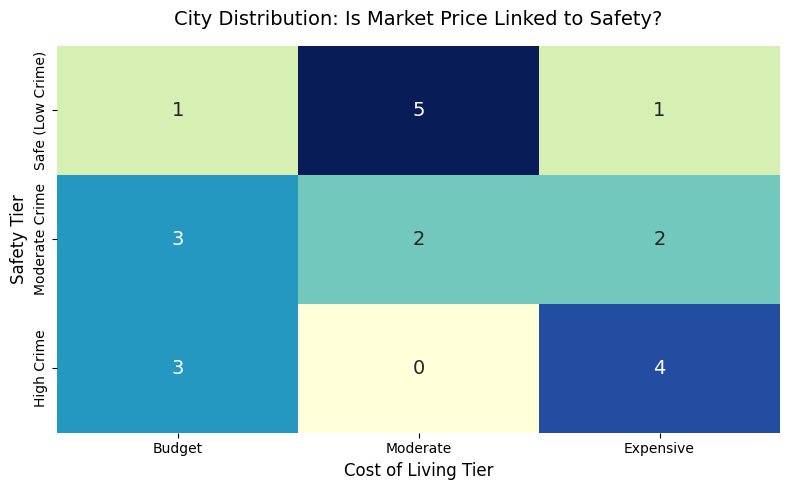

In [77]:
import pandas as pd

# 2. Convert raw metrics into meaningful text tiers
merged['Cost Tier'] = pd.qcut(merged['cost_one_person_inr'], q=3, labels=['Budget', 'Moderate', 'Expensive'])
merged['Safety Tier'] = pd.qcut(merged['total_crimes'], q=3, labels=['Safe (Low Crime)', 'Moderate Crime', 'High Crime'])

# Create a cross-tabulation showing the count of cities in each bucket
pivot_summary = pd.crosstab(merged['Safety Tier'], merged['Cost Tier'])

plt.figure(figsize=(8, 5))
sns.heatmap(pivot_summary, annot=True, cmap='YlGnBu', cbar=False, fmt='d', annot_kws={"size": 14})

plt.title('City Distribution: Is Market Price Linked to Safety?', fontsize=14, pad=15)
plt.xlabel('Cost of Living Tier', fontsize=12)
plt.ylabel('Safety Tier', fontsize=12)
plt.tight_layout()
plt.show()

#### overall heatmap and insights

C:\Users\HARSHIT\AppData\Local\Temp\ipykernel_28300\595756048.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


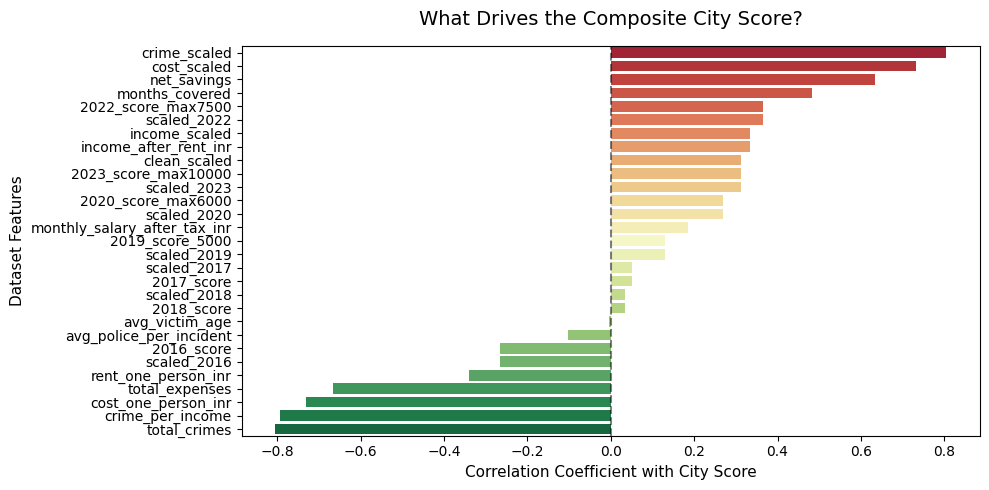

In [80]:
# Calculate correlations of all features specifically with the city_score
score_correlations = numeric_df.corr()['city_score'].sort_values(ascending=False)

# Drop 'city_score' itself and duplicate metric columns (like USD equivalents) so it stays clean
redundant_cols = ['city_score', 'cost_one_person_usd', 'rent_one_person_usd', 'monthly_salary_after_tax_usd']
score_correlations = score_correlations.drop(labels=redundant_cols, errors='ignore')

# Plot as a clean horizontal bar chart
plt.figure(figsize=(10, 5))
sns.barplot(
    x=score_correlations.values, 
    y=score_correlations.index, 
    palette='RdYlGn'  # Green for positive drivers, Red for negative drags
)

plt.axvline(x=0, color='black', linestyle='--', alpha=0.5)
plt.title('What Drives the Composite City Score?', fontsize=14, pad=15)
plt.xlabel('Correlation Coefficient with City Score', fontsize=11)
plt.ylabel('Dataset Features', fontsize=11)
plt.tight_layout()
plt.show()

-> The city_score is heavily dominated by income metrics, inherently rewarding wealthier cities over lifestyle indicators like safety or cleanliness.

-> Higher living costs drag down individual scores but correlate with increased crime, reflecting rapid urbanization, high density, and higher reporting rates in tier-1 hubs.

-> Cleanliness scores remain remarkably stable across years, indicating that sanitation profiles are deeply structural and resistant to quick governance fixes.

-> A positive correlation between crime and police deployment reveals a reactive strategy; law enforcement resources are funneled into areas after crimes occur rather than deterring them.

-> Crime and net income show a flat correlation. Economic prosperity neither drives up crime nor guarantees safety—they operate on independent social axes.

C:\Users\HARSHIT\AppData\Local\Temp\ipykernel_28300\4275794019.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


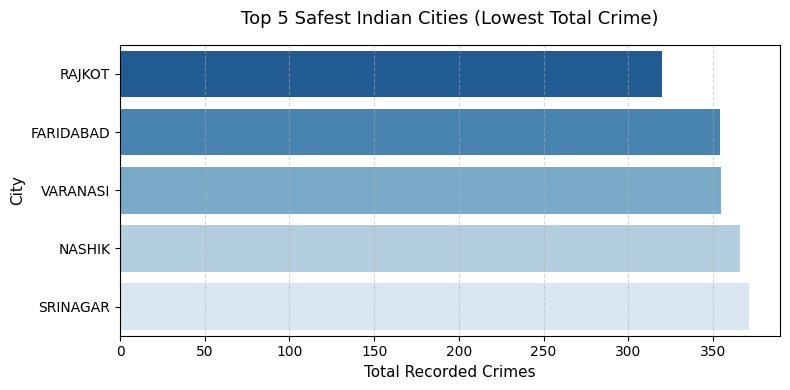

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Get the top 5 safest cities from your sorted data
safest_5 = merged.sort_values(by='total_crimes', ascending=True).head(5)

# 2. Plot a simple, clean horizontal bar chart
plt.figure(figsize=(8, 4))
sns.barplot(
    x='total_crimes', 
    y='city', 
    data=safest_5, 
    palette='Blues_r'
)

# 3. Add clean, standard text labels
plt.title('Top 5 Safest Indian Cities (Lowest Total Crime)', fontsize=13, pad=15)
plt.xlabel('Total Recorded Crimes', fontsize=11)
plt.ylabel('City', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [55]:
merged.sort_values(by='city_score', ascending=False) #nashik?

,city,2023_score_max10000,2022_score_max7500,2020_score_max6000,2019_score_5000,2018_score,2017_score,2016_score,cost_one_person_usd,rent_one_person_usd,...,income_after_rent_inr,total_crimes,avg_police_per_incident,avg_victim_age,crime_per_income,clean_scaled,income_scaled,crime_scaled,cost_scaled,city_score
10,VARANASI,7107.10,4734.69,3684.20,3063,3052,1515,839,273,74.7,...,24716.09,355,10.261972,44.526761,0.011349,67.971460,72.943929,98.389324,96.442661,83.936843
8,NASHIK,7372.20,4991.86,4729.46,3093,2786,1106,1232,350,114.0,...,39275.12,366,9.953552,45.918033,0.007425,71.759798,98.753895,97.883111,66.007889,83.601173
14,AGRA,6164.60,4441.29,4391.51,2970,0,879,1081,264,109.0,...,39978.03,764,10.212042,43.691099,0.015417,54.502922,100.000000,79.567418,100.000000,83.517585
3,BHOPAL,8855.20,6608.41,5066.31,3794,3689,1800,1336,339,107.0,...,18363.53,690,9.889855,44.198551,0.024851,92.952203,61.682234,82.972849,70.355707,76.990748
16,MEERUT,5850.40,5283.65,2314.59,0,0,708,760,350,135.0,...,37254.25,395,9.772152,44.987342,0.008042,50.012933,95.171336,96.548550,66.007889,76.935177
0,INDORE,9348.39,7146.41,5647.56,4659,3707,1808,1276,361,128.0,...,17924.22,699,9.989986,43.811159,0.023962,100.000000,60.903434,82.558675,61.660070,76.280545
2,VISAKHAPATNAM,8879.30,6701.18,4918.44,3744,3547,1797,1643,310,111.0,...,9752.88,728,10.068681,44.285714,0.037322,93.296598,46.417441,81.224114,81.818157,75.689078
7,RAJKOT,7465.80,5846.00,5157.36,4000,3000,1638,1574,324,104.0,...,9840.75,320,9.615625,43.693750,0.016861,73.097364,46.573215,100.000000,76.284574,73.988788
9,GHAZIABAD,7222.50,5387.67,4283.26,3877,2993,672,820,372,119.0,...,29434.37,704,10.176136,44.654830,0.017648,69.620552,81.308404,82.328578,57.312252,72.642446
12,KANPUR,6409.60,4165.43,3783.88,3113,2771,1053,1090,320,99.6,...,29205.93,1112,10.101619,44.130396,0.029296,58.004027,80.903430,63.552692,77.865579,70.081432


In [56]:
#top 5 safest
top_safest = merged.sort_values(by='total_crimes', ascending=True)
print(top_safest[['city', 'total_crimes']].head(5))

         city  total_crimes
7      RAJKOT           320
20  FARIDABAD           354
10   VARANASI           355
8      NASHIK           366
19   SRINAGAR           371


In [57]:
#top 5 most expensive
most_expensive = merged.sort_values(by='cost_one_person_inr', ascending=False)
print(most_expensive[['city', 'cost_one_person_inr']].head(5))

         city  cost_one_person_inr
4        PUNE             45425.58
6       THANE             42789.67
17    CHENNAI             41295.99
5   AHMEDABAD             38835.80
18   LUDHIANA             37517.84


In [58]:
#Worst Overall (Lowest city_score)
worst_overall = merged.sort_values(by='city_score', ascending=True)
print(worst_overall[['city', 'city_score']].head(1))

       city  city_score
17  CHENNAI   25.248247


In [59]:
cols = ['city','clean_scaled','income_scaled','cost_scaled','crime_scaled','city_score']
merged.loc[merged['city']=='FARIDABAD', cols]

,city,clean_scaled,income_scaled,cost_scaled,crime_scaled,city_score
20,FARIDABAD,0.0,93.457943,52.964389,98.435343,61.214419


In [60]:
merged.sort_values('city_score', ascending=False).head(5)[cols]

,city,clean_scaled,income_scaled,cost_scaled,crime_scaled,city_score
10,VARANASI,67.971460,72.943929,96.442661,98.389324,83.936843
8,NASHIK,71.759798,98.753895,66.007889,97.883111,83.601173
14,AGRA,54.502922,100.000000,100.000000,79.567418,83.517585
3,BHOPAL,92.952203,61.682234,70.355707,82.972849,76.990748
16,MEERUT,50.012933,95.171336,66.007889,96.548550,76.935177


In [61]:
merged['affordability_flag'] = (merged['income_after_rent_inr'] < 0).astype(int)

In [62]:
merged[merged['affordability_flag'] == 1][['city', 'income_after_rent_inr']]

,city,income_after_rent_inr
1,SURAT,-16430.53


<Axes: xlabel='cost_one_person_inr', ylabel='income_after_rent_inr'>

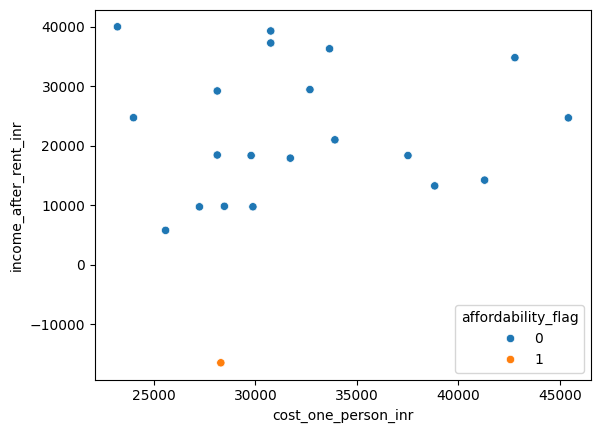

In [63]:
sns.scatterplot(
    x='cost_one_person_inr',
    y='income_after_rent_inr',
    hue='affordability_flag',
    data=merged
)

C:\Users\HARSHIT\AppData\Local\Temp\ipykernel_14400\2106131750.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=merged.sort_values('2023_score_max10000', ascending=False),


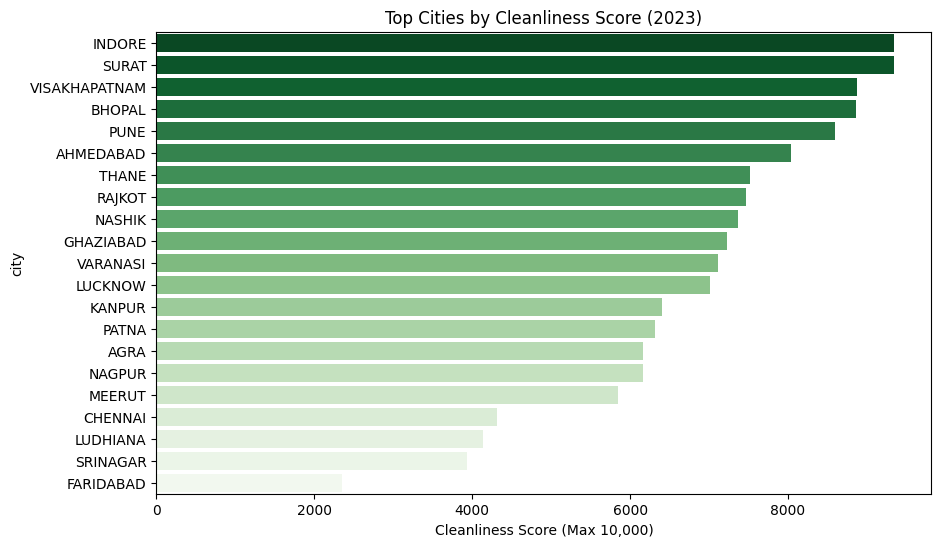

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
# Ranking cities by their 2023 cleanliness score
sns.barplot(data=merged.sort_values('2023_score_max10000', ascending=False), 
            x='2023_score_max10000', y='city', palette='Greens_r')
plt.title('Top Cities by Cleanliness Score (2023)')
plt.xlabel('Cleanliness Score (Max 10,000)')
plt.show()

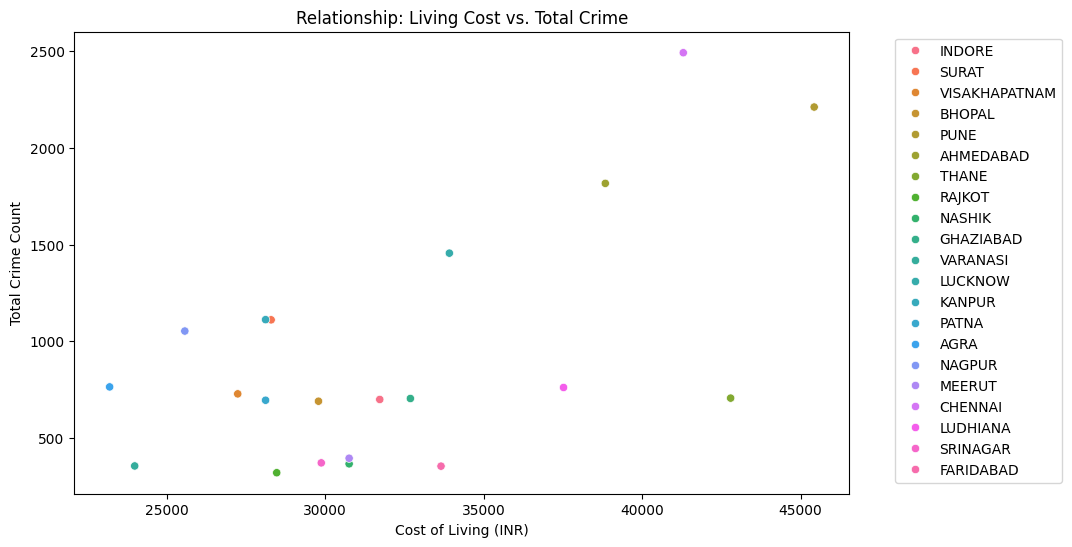

In [65]:
plt.figure(figsize=(10, 6))
# Using cost on X and total crimes on Y
sns.scatterplot(data=merged, x='cost_one_person_inr', y='total_crimes', 
                hue='city', sizes=(50, 400))
plt.title('Relationship: Living Cost vs. Total Crime')
plt.xlabel('Cost of Living (INR)')
plt.ylabel('Total Crime Count')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.show()